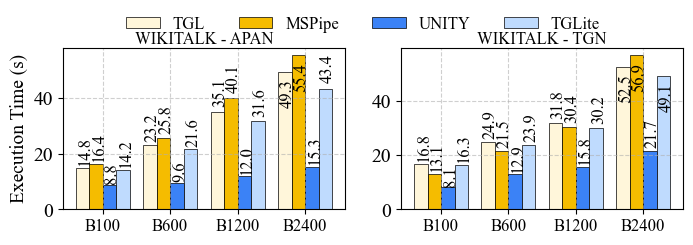

In [12]:
import yaml
import numpy as np
import mycolors
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size=16)

# 读取 YAML 文件
yaml_file = "batch_size.yaml"
with open(yaml_file, "r") as file:
    batch_data = yaml.safe_load(file)

# 设定子图结构
fig = plt.figure(figsize=(8, 2.1))
outer_gs = gridspec.GridSpec(1, 2, wspace=0.2, hspace=0.3)

# === 基线与颜色（新增 TGLite） ===
baseline_labels = ["TGL", "MSPipe", "UNITY", "TGLite"]
# 你也可以换成 mycolors 的配色；这里给出 4 种区分度较好的颜色
colors = ['#FFF6da', '#F5BC00', '#3B82F6', '#BFDBFE']  # 浅黄、金色、蓝色、红色

handles, labels = [], []

# 遍历数据集和模型进行绘图
for row_idx, (dataset, models) in enumerate(batch_data.items()):
    for col_idx, (model, values) in enumerate(models.items()):
        ax = fig.add_subplot(outer_gs[row_idx, col_idx])

        # 设定 x 轴
        batch_sizes = list(values["TGL"].keys())
        x_base = np.arange(len(batch_sizes))

        # 为 4 根柱子设置更合适的宽度与对齐（对称分布）
        num_bases = len(baseline_labels)  # 4
        bar_width = 0.20
        center_shift = (num_bases - 1) / 2.0  # 1.5 -> offsets: -1.5, -0.5, 0.5, 1.5

        # 绘制不同的 baseline
        for baseline_idx, baseline in enumerate(baseline_labels):
            # 若某 baseline 不在 YAML 中则跳过（更健壮）
            if baseline not in values:
                continue

            x_offset = x_base + (baseline_idx - center_shift) * bar_width
            heights = [values[baseline][bs] for bs in batch_sizes]

            bars = ax.bar(
                x_offset, heights, width=bar_width,
                color=colors[baseline_idx], edgecolor='black', linewidth=0.5, alpha=1,
                label=baseline if (row_idx == 0 and col_idx == 0) else ""
            )

            # 添加数据标签
            for bar in bars:
                height = bar.get_height()
                # 先尝试顶端上方 5%，若过高就压低到柱内
                label_height = height * 1.05
                try_ylim_top = ax.get_ylim()[1]
                if label_height > try_ylim_top * 0.8:
                    label_height = height * 0.95
                    va = 'top'
                else:
                    va = 'bottom'
                ax.text(
                    bar.get_x() + bar.get_width()/1.4, label_height,
                    f'{height:.1f}', ha='center', va=va, fontsize=12, rotation=90
                )

        # 设置子图属性
        ax.set_title(f"{dataset} - {model}", fontsize=12, pad=2)
        ax.set_xticks(x_base)
        ax.set_xticklabels(batch_sizes, rotation=0, ha='center', fontsize=12)
        ax.tick_params(axis='y', labelsize=14)
        ax.grid(True, which='both', linestyle='--', alpha=0.6)
        if col_idx == 0:
            ax.set_ylabel('Execution Time (s)', fontsize=14)

        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# 添加统一图例（去重）
unique_legend = dict(zip(labels, handles))
fig.legend(
    unique_legend.values(), unique_legend.keys(),
    loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.10),
    fontsize=12, frameon=False
)

plt.savefig('exp3.pdf', bbox_inches='tight')
plt.show()
